# Neon Syndicate OpenEnv — TRL PPO Training Notebook

**What this does:** Trains Qwen2.5-0.5B with TRL PPO against the Neon Syndicate **HTTP API** (env), then plots reward curves.

**Important — Hugging Face Space hardware does not speed up this notebook by itself.** The **LLM + PPO** run in Colab (or your laptop). A Space can only run the small FastAPI **game server**. Upgrading a Space to GPU helps that server a little, but the slow part is usually **billions of matmuls per step in Colab** plus **one HTTP round-trip per environment step** if you call a remote Space.

| Speed lever | Effect |
|-------------|--------|
| **Colab: Runtime → GPU** (L4, A100, T4) | Biggest win for the model. |
| **`MAX_NEW_TOKENS` 32–64** (not 128) | Cuts autoregressive decode; JSON actions are short. |
| **bf16 on CUDA** (default in config below) | ~2× faster than fp32 on many GPUs. |
| **`attn_implementation="sdpa"`** | Faster attention. |
| **`http://127.0.0.1:7860` instead of the Space** | Clone repo, run `uvicorn` in Colab → removes network latency. |
| Fewer `EPISODES` / `MAX_STEPS` | Shorter wall-clock; good for smoke tests. |

| Item | Value |
|------|-------|
| Environment | remote Space (default) or local API |
| Model | `Qwen/Qwen2.5-0.5B-Instruct` |

In [11]:
!pip3 install -q -U pip
!pip3 install  "trl==0.11.4" "transformers==4.44.2" "accelerate>=0.34.0" "torch>=2.2.0" "httpx>=0.27.0" "matplotlib>=3.8.0" "sentencepiece"

python(89360) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
python(89423) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Configuration — point at your Hugging Face Space (environment API)

The **game environment** is the FastAPI app running on a **Hugging Face Space**. Training calls `GET /health`, `GET /tasks`, `POST /reset`, `POST /step` on that host.

**1. Find your Space API base URL**

- Open your Space in the browser: `https://huggingface.co/spaces/<OWNER>/<REPO_NAME>`.
- When the Space finishes building and the app loads, the address bar is usually  
  **`https://<OWNER>-<REPO_NAME>.hf.space`** (same `OWNER` and `REPO_NAME` as in the URL above, lowercased; hyphens in the repo name stay hyphens).
- Use that **origin only** (no path): e.g. `https://hsbharadwaj-ev.hf.space` — **not** `huggingface.co/spaces/...` (that is the website, not the live API host).

**2. Set it in the next cell**

- Edit **`HF_SPACE_OWNER`** and **`HF_SPACE_REPO`** to match `https://huggingface.co/spaces/OWNER/REPO_NAME`, **or**
- Set **`ENV_BASE_URL`** directly to your `.hf.space` URL, **or**
- In Colab: **Secrets** (key icon) → add secret **`HF_SPACE_ENV_URL`** with your full base URL — it overrides the variables above.

**Local Colab server (optional):** use `http://127.0.0.1:7860` if you clone this repo and run `uvicorn` here (faster, no round trip to HF).

**Other knobs:** `EPISODES`, `MAX_STEPS`, `MAX_NEW_TOKENS`, `USE_FP32`.

In [12]:
import os

# --- Hugging Face Space = environment API (see https://huggingface.co/spaces/OWNER/REPO) ---
HF_SPACE_OWNER = "hsbharadwaj"  # your HF username or org
HF_SPACE_REPO = "ev"           # your Space repo name

# If the auto-built URL is wrong, paste the origin from the browser when the Space loads:
ENV_BASE_URL_OVERRIDE = "https://hsbharadwaj-ev.hf.space/"  # e.g. "https://hsbharadwaj-ev.hf.space"


def _hf_space_api_base() -> str:
    """Typical Space runtime host: https://OWNER-REPO.hf.space"""
    o = HF_SPACE_OWNER.strip().lower().replace("_", "-")
    r = HF_SPACE_REPO.strip().lower().replace("_", "-")
    return f"https://{o}-{r}.hf.space"


# Priority: env / Colab secret → explicit override → built from OWNER/REPO
_secret_or_env = os.environ.get("HF_SPACE_ENV_URL", "").strip()
if not _secret_or_env:
    try:
        from google.colab import userdata

        _secret_or_env = str(userdata.get("HF_SPACE_ENV_URL")).strip()
    except Exception:
        _secret_or_env = ""

if _secret_or_env:
    ENV_BASE_URL = _secret_or_env.rstrip("/")
elif ENV_BASE_URL_OVERRIDE.strip():
    ENV_BASE_URL = ENV_BASE_URL_OVERRIDE.strip().rstrip("/")
else:
    ENV_BASE_URL = _hf_space_api_base()

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
EPISODES = 6                # increase when debugging is done
MAX_STEPS = 8               # cap steps per episode (env max is often 12; lower = faster)
MAX_NEW_TOKENS = 64         # try 32–64; 128 is usually overkill for one JSON action
LEARNING_RATE = 1e-5
SEED = 42
OUTPUT_DIR = "artifacts/trl-neon-model"

# Performance: on CUDA, bf16 is much faster than fp32. Set True only if you see NaNs / instability.
USE_FP32 = False
ATTN_IMPLEMENTATION = "sdpa"  # "eager" if you hit a compatibility error

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("artifacts", exist_ok=True)
print("Environment API:", ENV_BASE_URL)

Environment API: https://hsbharadwaj-ev.hf.space


## Verify Environment is Reachable

In [13]:
import httpx

resp = httpx.get(f"{ENV_BASE_URL}/health", timeout=15)
print("Health check:", resp.json())

resp2 = httpx.get(f"{ENV_BASE_URL}/tasks", timeout=15)
tasks = resp2.json()["tasks"]
print(f"Available tasks: {len(tasks)}")
for t in tasks:
    print(f"  {t['task_id']} ({t['difficulty']}) — {t['title']}")

Health check: {'status': 'ok'}
Available tasks: 6
  task_easy_docklands_relay (easy) — Docklands Relay Hijack
  task_easy_data_spire_broker (easy) — Data Spire Broker Run
  task_medium_undergrid_blackout (medium) — Undergrid Blackout Play
  task_medium_citadel_convoy (medium) — Citadel Convoy Diversion
  task_hard_orchid_coup (hard) — Orchid Coup Containment
  task_hard_citywide_failsafe (hard) — Citywide Failsafe Cascade


## Environment Client & Helpers

All the logic from `train_trl_ppo.py` is inlined below so this notebook is fully self-contained.

In [14]:
from __future__ import annotations

import json
import random
from dataclasses import dataclass
from typing import Any, Dict, List

import httpx
import torch

ALLOWED_ACTION_TYPES = {
    "scout_sector",
    "negotiate_pact",
    "trade_resources",
    "deploy_asset",
    "run_operation",
    "secure_extraction",
    "noop",
}


@dataclass
class EpisodeResult:
    episode_id: int
    task_id: str
    total_reward: float
    final_task_score: float
    success: bool
    steps: int


class OpenEnvEpisodeRunner:
    """Thin HTTP client that talks to the Neon Syndicate OpenEnv API."""

    def __init__(self, env_base_url: str, timeout: float = 30.0) -> None:
        self.env_base_url = env_base_url.rstrip("/")
        self.client = httpx.Client(timeout=timeout)

    def close(self) -> None:
        self.client.close()

    def tasks(self) -> List[Dict[str, Any]]:
        resp = self.client.get(f"{self.env_base_url}/tasks")
        resp.raise_for_status()
        return resp.json()["tasks"]

    def reset(self, task_id: str) -> Dict[str, Any]:
        resp = self.client.post(f"{self.env_base_url}/reset", json={"task_id": task_id})
        resp.raise_for_status()
        return resp.json()["observation"]

    def step(self, action: Dict[str, Any]) -> Dict[str, Any]:
        resp = self.client.post(f"{self.env_base_url}/step", json=action)
        resp.raise_for_status()
        return resp.json()


def build_prompt(observation: Dict[str, Any]) -> str:
    mission = observation.get("mission", {})
    return (
        "You are a strategic planner in Neon Syndicate. Return only one JSON action.\n"
        "Goal: maximize mission completion score in this partially observable environment.\n\n"
        f"Task: {observation.get('task_id')} ({observation.get('difficulty')})\n"
        f"Objective: {observation.get('objective')}\n"
        f"Step: {observation.get('step_count')}/{observation.get('max_steps')}\n"
        f"Threat: {observation.get('known_threat')}\n"
        f"Mission ID: {mission.get('mission_id')}\n"
        f"Stakes: {mission.get('stakes')}\n"
        f"Rumors: {mission.get('rumors')}\n"
        f"Resources: {observation.get('resources')}\n"
        f"Reputation: {observation.get('reputation')}\n"
        f"Alliances: {observation.get('alliances')}\n"
        f"Deployed Sector: {observation.get('deployed_sector')}\n"
        f"Operation Ready: {observation.get('operation_ready')}\n"
        f"Operation Executed: {observation.get('operation_executed')}\n"
    )


def extract_json_object(text: str) -> Dict[str, Any]:
    content = (text or "{}").strip()
    if content.startswith("```"):
        lines = content.split("\n")
        if len(lines) >= 3 and lines[-1].strip().startswith("```"):
            content = "\n".join(lines[1:-1])
        else:
            content = "\n".join(lines[1:])
    return json.loads(content)


def heuristic_fallback(observation: Dict[str, Any]) -> Dict[str, Any]:
    alliances = observation.get("alliances", [])
    resources = observation.get("resources", {})

    if len(alliances) < 1:
        return {"action_type": "negotiate_pact", "faction": "ghostwire"}
    if resources.get("intel", 0) < 45:
        return {"action_type": "scout_sector", "sector": "undergrid"}
    if not observation.get("operation_ready"):
        return {"action_type": "deploy_asset", "sector": "undergrid"}
    if not observation.get("operation_executed"):
        return {"action_type": "run_operation", "operation_code": "OP-NIGHTLOCK"}
    return {
        "action_type": "secure_extraction",
        "sector": "undergrid",
        "message": "Extraction window green. Fallback stable. Team confirms clean exit.",
    }


def normalize_action(action: Dict[str, Any], observation: Dict[str, Any]) -> Dict[str, Any]:
    if not isinstance(action, dict):
        return heuristic_fallback(observation)
    action_type = action.get("action_type")
    if action_type not in ALLOWED_ACTION_TYPES:
        return {"action_type": "noop"}
    return action


def select_task(task_list: List[Dict[str, Any]], idx: int) -> str:
    if not task_list:
        raise RuntimeError("No tasks returned by environment")
    return task_list[idx % len(task_list)]["task_id"]


print("Helpers loaded.")

Helpers loaded.


## Load Model & Tokenizer

In [15]:
import torch
from transformers import AutoTokenizer
from trl import AutoModelForCausalLMWithValueHead, PPOConfig, PPOTrainer

if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

if torch.cuda.is_available():
    device = torch.device("cuda")
    dtype = torch.float32 if USE_FP32 else (
        torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    )
else:
    device = torch.device("cpu")
    dtype = torch.float32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLMWithValueHead.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
    attn_implementation=ATTN_IMPLEMENTATION,
)
model = model.to(device)
print(f"Model loaded on: {device}  dtype: {dtype}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
if torch.cuda.is_available():
    import subprocess
    subprocess.call(["nvidia-smi", "-L"])

Model loaded on: cpu  dtype: torch.float32
Parameters: 494,033,665


## Initialize PPO Trainer

Hugging Face **Accelerate** keeps a process-wide singleton. If you see  
`AcceleratorState has already been initialized... pass cpu=True`, either **restart the kernel** or run the next cell as-is: it resets that state so you can re-run after changing `device` / GPU settings.

In [19]:
from accelerate.state import AcceleratorState

# Clear singleton so this cell works when re-run or after other libraries touched Accelerate.
AcceleratorState._reset_state(reset_partial_state=True)

ppo_config = PPOConfig(
    model_name=MODEL_NAME,
    learning_rate=LEARNING_RATE,
    batch_size=1,
    mini_batch_size=1,
    gradient_accumulation_steps=1,
    accelerator_kwargs={"cpu": True} if device.type == "cpu" else {},
    log_with=None,
)

trainer = PPOTrainer(
    config=ppo_config,
    model=model,
    tokenizer=tokenizer,
)

print("PPO Trainer ready.")

PPO Trainer ready.


/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:273: UserWarning: No dataset is provided. Make sure to set config.batch_size to the correct value before training.
  warnings.warn(


## Run PPO Training Loop

Each episode: reset the environment, generate actions with the LLM, step through the game, and update via PPO rewards.

In [20]:
random.seed(SEED)
torch.manual_seed(SEED)

runner = OpenEnvEpisodeRunner(ENV_BASE_URL)
all_tasks = runner.tasks()
results: List[EpisodeResult] = []

for episode in range(EPISODES):
    task_id = select_task(all_tasks, episode)
    observation = runner.reset(task_id)
    total_reward = 0.0
    final_task_score = 0.0
    success = False

    for step_num in range(MAX_STEPS):
        prompt = build_prompt(observation)
        query_tensor = tokenizer.encode(prompt, return_tensors="pt").squeeze(0)
        query_tensor = query_tensor.to(model.pretrained_model.device)

        dev = model.pretrained_model.device
        response_tensor = trainer.generate(
            query_tensor,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True,
            top_p=0.9,
            temperature=0.8,
            pad_token_id=tokenizer.pad_token_id,
        ).squeeze(0)

        response_text = tokenizer.decode(response_tensor, skip_special_tokens=True)
        try:
            parsed_action = extract_json_object(response_text)
            action = normalize_action(parsed_action, observation)
        except Exception:
            action = heuristic_fallback(observation)

        step_payload = runner.step(action)
        reward_value = float(step_payload["reward"]["score"])
        done = bool(step_payload["done"])

        reward_t = torch.tensor(reward_value, dtype=torch.float32, device=dev)
        trainer.step(
            [query_tensor],
            [response_tensor],
            [reward_t],
        )

        total_reward += reward_value
        observation = step_payload["observation"]

        if done:
            info = step_payload.get("info", {})
            final_task_score = float(info.get("task_score", 0.0))
            success = bool(info.get("success", False))
            break

    results.append(
        EpisodeResult(
            episode_id=episode,
            task_id=task_id,
            total_reward=total_reward,
            final_task_score=final_task_score,
            success=success,
            steps=int(observation.get("step_count", 0)),
        )
    )

    print(
        f"[TRAIN] episode={episode} task={task_id} total_reward={total_reward:.3f} "
        f"task_score={final_task_score:.3f} success={success}",
        flush=True,
    )

runner.close()
print(f"\nFinished {len(results)} episodes.")

/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1246: UserWarning: The average ratio of batch (14.93) exceeds threshold 10.00. Skipping batch.
  warnings.warn(
/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1246: UserWarning: The average ratio of batch (14.25) exceeds threshold 10.00. Skipping batch.
  warnings.warn(
/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1246: UserWarning: The average ratio of batch (14.33) exceeds threshold 10.00. Skipping batch.
  warnings.warn(
/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1309: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/at

[TRAIN] episode=0 task=task_easy_docklands_relay total_reward=0.279 task_score=0.000 success=False


/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -27.44 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -15.04 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence i

[TRAIN] episode=1 task=task_easy_data_spire_broker total_reward=0.077 task_score=0.000 success=False


/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -2.47 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -49.53 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is

...

/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -35.15 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


[TRAIN] episode=4 task=task_hard_orchid_coup total_reward=0.106 task_score=0.000 success=False


/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -13.10 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -15.86 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence i

[TRAIN] episode=5 task=task_hard_citywide_failsafe total_reward=0.107 task_score=0.000 success=False

Finished 6 episodes.


/Users/chinmayabharadwajhs/Scalar/Scalar-Openev/.venv/lib/python3.10/site-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -34.76 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


## Save Model & Training Summary

In [21]:
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

summary_path = f"{OUTPUT_DIR}/training_summary.jsonl"
with open(summary_path, "w", encoding="utf-8") as handle:
    for item in results:
        handle.write(json.dumps(item.__dict__) + "\n")

avg_reward = sum(r.total_reward for r in results) / max(1, len(results))
avg_score = sum(r.final_task_score for r in results) / max(1, len(results))
success_rate = sum(1 for r in results if r.success) / max(1, len(results))

print(f"Model saved to: {OUTPUT_DIR}")
print(f"Episodes:       {len(results)}")
print(f"Avg Reward:     {avg_reward:.3f}")
print(f"Avg Task Score: {avg_score:.3f}")
print(f"Success Rate:   {success_rate:.1%}")

Model saved to: artifacts/trl-neon-model
Episodes:       6
Avg Reward:     0.175
Avg Task Score: 0.090
Success Rate:   0.0%


## Plot Reward Curves

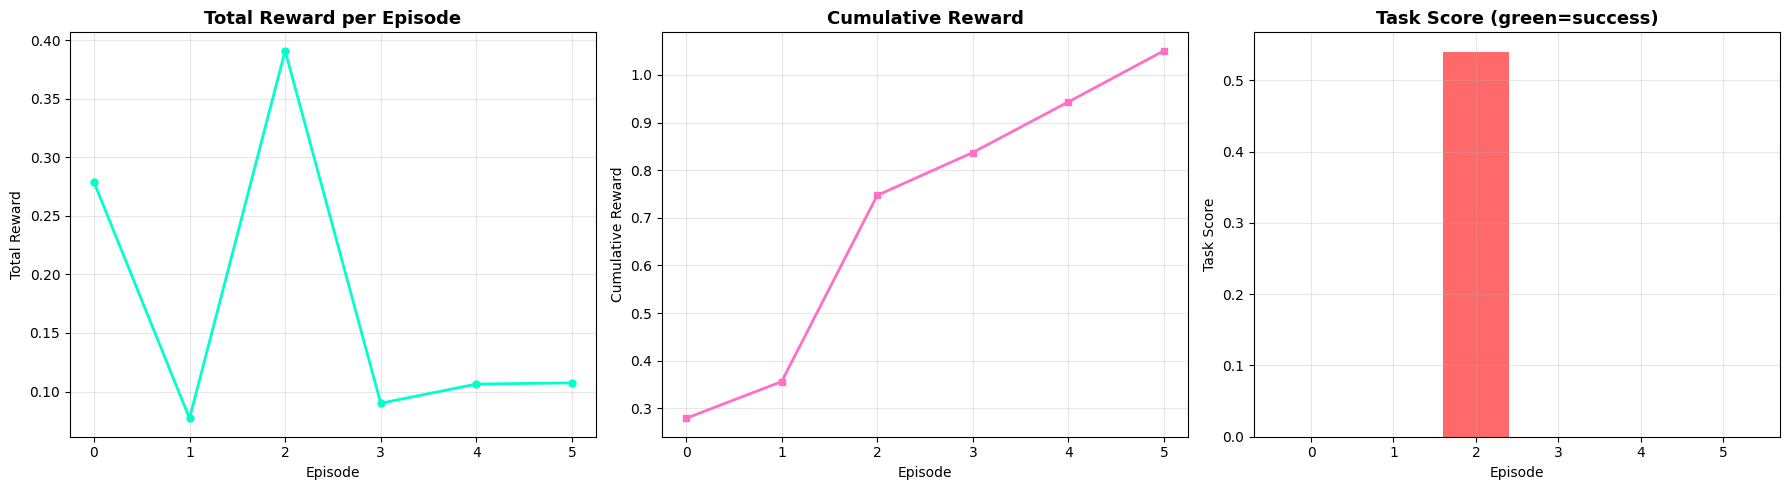

Saved: artifacts/reward_curves.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

episodes_x = [r.episode_id for r in results]
rewards = [r.total_reward for r in results]
scores = [r.final_task_score for r in results]
cumulative = list(np.cumsum(rewards))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(episodes_x, rewards, "o-", color="#00ffcc", linewidth=2, markersize=5)
axes[0].set_title("Total Reward per Episode", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].grid(True, alpha=0.3)

axes[1].plot(episodes_x, cumulative, "s-", color="#ff6ec7", linewidth=2, markersize=5)
axes[1].set_title("Cumulative Reward", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Cumulative Reward")
axes[1].grid(True, alpha=0.3)

axes[2].bar(episodes_x, scores, color=["#00ff88" if r.success else "#ff4444" for r in results], alpha=0.8)
axes[2].set_title("Task Score (green=success)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Task Score")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/reward_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: artifacts/reward_curves.png")

## (Optional) Upload Trained Model to Hugging Face

Uncomment and run the cell below to push the trained model to the HF Hub.

In [ ]:
# from huggingface_hub import HfApi, login
# login()  # will prompt for your HF token
#
# api = HfApi()
# api.upload_folder(
#     folder_path=OUTPUT_DIR,
#     repo_id="hsbharadwaj/ev",
#     repo_type="space",
#     path_in_repo="artifacts/trl-neon-model",
# )
# print("Model uploaded to HF Space!")